In [1]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# -----------------------------
# Simulation choice
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'
SIM_PATH = os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/'   # e_ff = 0.03

# -----------------------------
# Model setup
# -----------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

iso_dir = '/scratch/wyz5rge/synthetic-hr/euclidean_cmd_metric_isochrones'
os.makedirs(iso_dir, exist_ok=True)

# Build all needed filters at once
ALL_FILTERS = [
    'jwst,F115W',
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F200W',
]

FILTER_KEY_MAP = {
    'jwst,F115W': 'm_jwst_F115W',
    'jwst,F162M': 'm_jwst_F162M',
    'jwst,F182M': 'm_jwst_F182M',
    'jwst,F200W': 'm_jwst_F200W',
}

CMD_CHOICES = [
    ('jwst,F115W', 'jwst,F200W', 'jwst,F200W', 'F115W-F200W vs F200W'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F162M', 'F162M-F182M vs F162M'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F182M', 'F162M-F182M vs F182M'),
    ('jwst,F162M', 'jwst,F200W', 'jwst,F200W', 'F162M-F200W vs F200W'),
    ('jwst,F115W', 'jwst,F162M', 'jwst,F162M', 'F115W-F162M vs F162M'),
]

In [3]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    return converter.to_spicea_table(snapshot)


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr


def compute_dt90(cluster_table):
    _, ages_myr, _ = extract_masses_and_ages(cluster_table)
    if len(ages_myr) < 2:
        return np.nan
    return np.percentile(ages_myr, 95) - np.percentile(ages_myr, 5)

In [4]:
def build_isochrone_grid(ages_yr, increment_yr=0.1e6, min_age_floor_yr=0.5e6):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=ALL_FILTERS,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid

In [5]:
def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filter_keys):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, filter_keys)
    except Exception:
        return None

In [6]:
def cmd_coords_from_star(star, y_filter_key, filt_key_a, filt_key_b):
    """
    interpolator output:
    [lum, teff, logg, mag_a, mag_b]
    """
    if star is None:
        return None

    mag_a = float(star[3])
    mag_b = float(star[4])

    color = mag_a - mag_b

    if y_filter_key == filt_key_a:
        ymag = mag_a
    elif y_filter_key == filt_key_b:
        ymag = mag_b
    else:
        raise ValueError("y_filter_key must match one of the interpolated filters")

    return color, ymag


def euclidean_cmd_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

In [7]:
def compute_cmd_euclidean_metric(cluster_table, filt_a, filt_b, y_filter_name, increment_yr=0.1e6):
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
        ages_yr,
        increment_yr=increment_yr
    )

    filt_key_a = FILTER_KEY_MAP[filt_a]
    filt_key_b = FILTER_KEY_MAP[filt_b]

    if y_filter_name == filt_a:
        y_filter_key = filt_key_a
    elif y_filter_name == filt_b:
        y_filter_key = filt_key_b
    else:
        raise ValueError("y_filter_name must equal filt_a or filt_b")

    oldest_age_myr = np.max(ages_myr)

    distances = []
    actual_points = []
    oldest_points = []
    used_masses = []

    for m, a in zip(masses, ages_myr):
        actual_star = safe_interpolate(a, m, iso_grid, log_age_arr, [filt_key_a, filt_key_b])
        old_star = safe_interpolate(oldest_age_myr, m, iso_grid, log_age_arr, [filt_key_a, filt_key_b])

        if actual_star is None or old_star is None:
            continue

        actual_cmd = cmd_coords_from_star(actual_star, y_filter_key, filt_key_a, filt_key_b)
        oldest_cmd = cmd_coords_from_star(old_star, y_filter_key, filt_key_a, filt_key_b)

        if actual_cmd is None or oldest_cmd is None:
            continue

        d = euclidean_cmd_distance(actual_cmd, oldest_cmd)

        distances.append(d)
        actual_points.append(actual_cmd)
        oldest_points.append(oldest_cmd)
        used_masses.append(m)

    return {
        'metric_mean': np.mean(distances) if len(distances) > 0 else np.nan,
        'metric_median': np.median(distances) if len(distances) > 0 else np.nan,
        'metric_std': np.std(distances) if len(distances) > 0 else np.nan,
        'distances': np.array(distances),
        'actual_points': np.array(actual_points),
        'oldest_points': np.array(oldest_points),
        'masses': np.array(used_masses),
        'oldest_age_myr': oldest_age_myr,
        'n_valid': len(distances),
        'iso_grid': iso_grid,
        'level_age_arr_yr': level_age_arr_yr,
        'filt_key_a': filt_key_a,
        'filt_key_b': filt_key_b,
        'y_filter_key': y_filter_key,
    }

In [8]:
test_time = 1.5
cluster_table = load_cluster_table(SIM_PATH, test_time)

for cmd_choice in CMD_CHOICES:
    filt_a, filt_b, y_filter_name, title = cmd_choice
    result = compute_cmd_euclidean_metric(cluster_table, filt_a, filt_b, y_filter_name)

    print(title)
    print(f"  oldest age in snapshot = {result['oldest_age_myr']:.3f} Myr")
    print(f"  mean spread            = {result['metric_mean']:.4f}")
    print(f"  median spread          = {result['metric_median']:.4f}")
    print(f"  n valid                = {result['n_valid']}")
    print()

F115W-F200W vs F200W
  oldest age in snapshot = 1.499 Myr
  mean spread            = 0.2688
  median spread          = 0.1894
  n valid                = 2337

F162M-F182M vs F162M
  oldest age in snapshot = 1.499 Myr
  mean spread            = 0.2709
  median spread          = 0.1940
  n valid                = 2337

F162M-F182M vs F182M
  oldest age in snapshot = 1.499 Myr
  mean spread            = 0.2695
  median spread          = 0.1900
  n valid                = 2337

F162M-F200W vs F200W
  oldest age in snapshot = 1.499 Myr
  mean spread            = 0.2683
  median spread          = 0.1890
  n valid                = 2337

F115W-F162M vs F162M
  oldest age in snapshot = 1.499 Myr
  mean spread            = 0.2715
  median spread          = 0.1940
  n valid                = 2337



In [9]:
def plot_cmd_snapshot_with_oldest_anchor(cluster_table, cmd_choice):
    filt_a, filt_b, y_filter_name, title = cmd_choice
    result = compute_cmd_euclidean_metric(cluster_table, filt_a, filt_b, y_filter_name)

    iso_grid = result['iso_grid']
    level_age_arr_yr = result['level_age_arr_yr']
    filt_key_a = result['filt_key_a']
    filt_key_b = result['filt_key_b']
    y_filter_key = result['y_filter_key']

    grid_ages_myr = level_age_arr_yr / 1e6
    idx_oldest = np.argmax(grid_ages_myr)

    plt.figure(figsize=(7, 6))

    # all isochrones lightly
    for iso in iso_grid:
        pts = iso.points
        x = np.array(pts[filt_key_a] - pts[filt_key_b], dtype=float)
        y = np.array(pts[y_filter_key], dtype=float)
        plt.plot(x, y, color='lightcoral', alpha=0.15, lw=1)

    # oldest isochrone strongly
    pts = iso_grid[idx_oldest].points
    x = np.array(pts[filt_key_a] - pts[filt_key_b], dtype=float)
    y = np.array(pts[y_filter_key], dtype=float)
    plt.plot(x, y, color='darkred', lw=2, label=f'oldest isochrone (~{grid_ages_myr[idx_oldest]:.2f} Myr)')

    # actual stars
    if len(result['actual_points']) > 0:
        plt.scatter(result['actual_points'][:, 0], result['actual_points'][:, 1],
                    s=5, alpha=0.5, color='k', label='cluster stars')

    plt.xlabel(f'{filt_a} - {filt_b}')
    plt.ylabel(y_filter_name)
    plt.title(f'{title}\nmean Euclidean spread = {result["metric_mean"]:.4f}')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

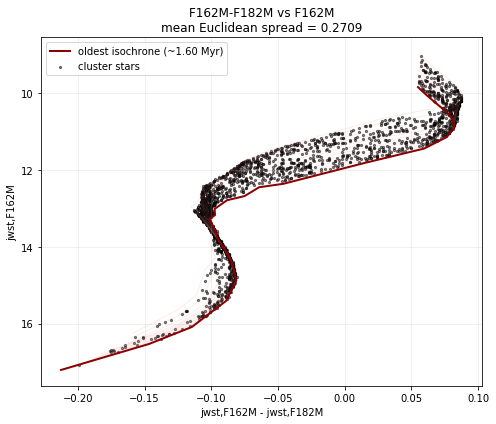

In [10]:
cluster_table = load_cluster_table(SIM_PATH, 1.5)
plot_cmd_snapshot_with_oldest_anchor(cluster_table, CMD_CHOICES[1])

In [11]:
def build_cmd_euclidean_time_series(sim_path, snapshot_times_myr, cmd_choice):
    filt_a, filt_b, y_filter_name, title = cmd_choice
    rows = []

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)
            result = compute_cmd_euclidean_metric(cluster_table, filt_a, filt_b, y_filter_name)

            rows.append({
                't_myr': t,
                'dt90': compute_dt90(cluster_table),
                'metric_mean': result['metric_mean'],
                'metric_median': result['metric_median'],
                'metric_std': result['metric_std'],
                'n_valid': result['n_valid'],
                'cmd_title': title,
            })

            print(f"{title}, t={t:.2f} done")
        except Exception as e:
            print(f"{title}, t={t:.2f} failed: {e}")

    return pd.DataFrame(rows)

In [12]:
times = np.arange(0.6, 6.6, 0.2)

all_dfs = []
for cmd_choice in CMD_CHOICES:
    df_cmd = build_cmd_euclidean_time_series(SIM_PATH, times, cmd_choice)
    all_dfs.append(df_cmd)

df_all_cmd = pd.concat(all_dfs, ignore_index=True)
df_all_cmd.head()

F115W-F200W vs F200W, t=0.60 done
F115W-F200W vs F200W, t=0.80 done
F115W-F200W vs F200W, t=1.00 done
F115W-F200W vs F200W, t=1.20 done
F115W-F200W vs F200W, t=1.40 done
F115W-F200W vs F200W, t=1.60 done
F115W-F200W vs F200W, t=1.80 done
F115W-F200W vs F200W, t=2.00 done
F115W-F200W vs F200W, t=2.20 done
F115W-F200W vs F200W, t=2.40 done
F115W-F200W vs F200W, t=2.60 done
F115W-F200W vs F200W, t=2.80 done
F115W-F200W vs F200W, t=3.00 done
F115W-F200W vs F200W, t=3.20 done
F115W-F200W vs F200W, t=3.40 done
F115W-F200W vs F200W, t=3.60 done
F115W-F200W vs F200W, t=3.80 done
F115W-F200W vs F200W, t=4.00 done
F115W-F200W vs F200W, t=4.20 done
F115W-F200W vs F200W, t=4.40 done
F115W-F200W vs F200W, t=4.60 done
F115W-F200W vs F200W, t=4.80 done
F115W-F200W vs F200W, t=5.00 done
F115W-F200W vs F200W, t=5.20 done
F115W-F200W vs F200W, t=5.40 done
F115W-F200W vs F200W, t=5.60 done
F115W-F200W vs F200W, t=5.80 done
F115W-F200W vs F200W, t=6.00 done
F115W-F200W vs F200W, t=6.20 done
F115W-F200W vs

,t_myr,dt90,metric_mean,metric_median,metric_std,n_valid,cmd_title
0,0.6,0.549636,0.050463,0.031145,0.054533,339,F115W-F200W vs F200W
1,0.8,0.755497,0.117191,0.084853,0.110859,737,F115W-F200W vs F200W
2,1.0,0.904656,0.175338,0.134002,0.158695,1264,F115W-F200W vs F200W
3,1.2,0.905484,0.191818,0.133236,0.190260,1554,F115W-F200W vs F200W
4,1.4,0.905549,0.262509,0.183367,0.247898,2166,F115W-F200W vs F200W


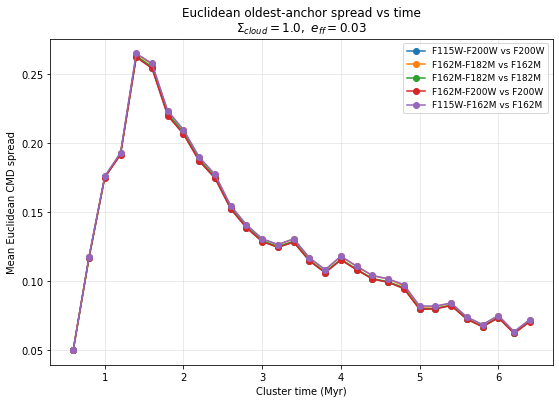

In [13]:
plt.figure(figsize=(9, 6))

for title in df_all_cmd['cmd_title'].unique():
    sub = df_all_cmd[(df_all_cmd['cmd_title'] == title) & np.isfinite(df_all_cmd['metric_mean'])].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['metric_mean'], marker='o', label=title)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Mean Euclidean CMD spread')
plt.title(r'Euclidean oldest-anchor spread vs time' '\n' r'$\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

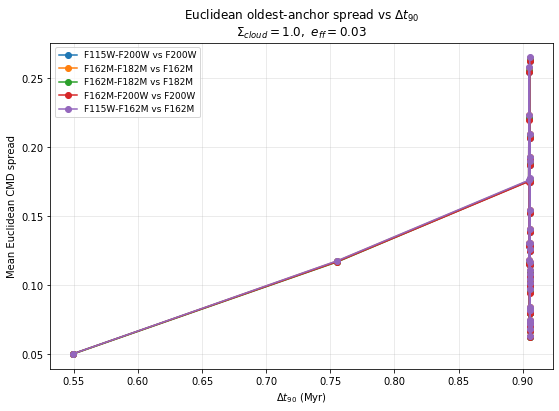

In [14]:
plt.figure(figsize=(9, 6))

for title in df_all_cmd['cmd_title'].unique():
    sub = df_all_cmd[(df_all_cmd['cmd_title'] == title) & np.isfinite(df_all_cmd['metric_mean'])].sort_values('dt90')
    plt.plot(sub['dt90'], sub['metric_mean'], marker='o', label=title)

plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel('Mean Euclidean CMD spread')
plt.title(r'Euclidean oldest-anchor spread vs $\Delta t_{90}$' '\n' r'$\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

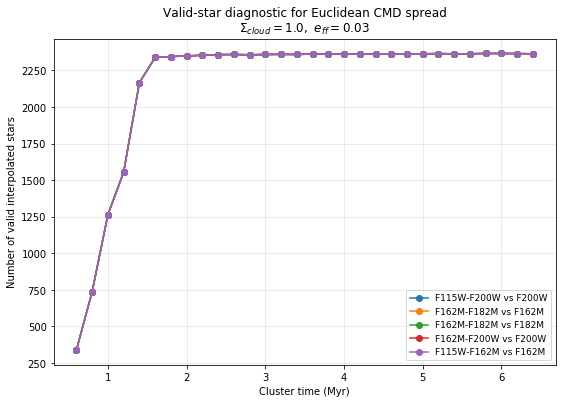

In [15]:
plt.figure(figsize=(9, 6))

for title in df_all_cmd['cmd_title'].unique():
    sub = df_all_cmd[df_all_cmd['cmd_title'] == title].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['n_valid'], marker='o', label=title)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Number of valid interpolated stars')
plt.title(r'Valid-star diagnostic for Euclidean CMD spread' '\n' r'$\Sigma_{cloud}=1.0,\ e_{ff}=0.03$')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

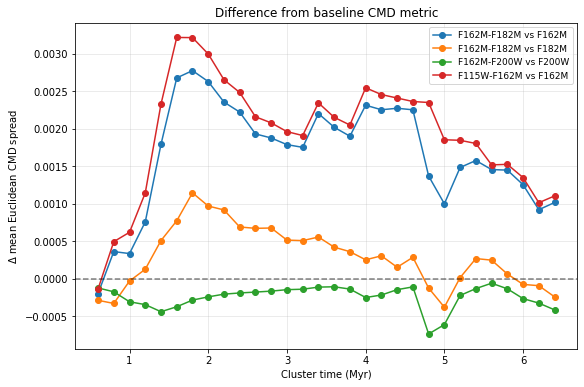

In [16]:
# Difference plot
baseline_title = 'F115W-F200W vs F200W'
baseline = df_all_cmd[df_all_cmd['cmd_title'] == baseline_title][['t_myr', 'metric_mean']].copy()
baseline = baseline.rename(columns={'metric_mean': 'baseline_metric'})

df_diff = df_all_cmd.merge(baseline, on='t_myr', how='left')
df_diff['delta_metric'] = df_diff['metric_mean'] - df_diff['baseline_metric']

plt.figure(figsize=(9, 6))
for title in df_diff['cmd_title'].unique():
    if title == baseline_title:
        continue
    sub = df_diff[(df_diff['cmd_title'] == title) & np.isfinite(df_diff['delta_metric'])].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['delta_metric'], marker='o', label=title)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Cluster time (Myr)')
plt.ylabel(r'$\Delta$ mean Euclidean CMD spread')
plt.title('Difference from baseline CMD metric')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()